# HW14: Эмбеддинги, FAISS, оценка retrieval и mini-RAG
В этом задании мы реализуем базовый RAG-конвейер для микро-базы знаний по основам тендеров и закупок.

## 1. Настройка окружения и фиксация seed
Сначала импортируем все необходимые библиотеки, зафиксируем seed для воспроизводимости и проверим доступные устройства.

In [9]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

try:
    import faiss
    import torch
    from sentence_transformers import SentenceTransformer
    HAS_NN_LIBS = True
except Exception as e:
    HAS_NN_LIBS = False
    print(f"Не найдены faiss/sentence_transformers. Будет использован fallback на TF-IDF. Ошибка: {e}")

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    if HAS_NN_LIBS:
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)

device = "cuda" if HAS_NN_LIBS and torch.cuda.is_available() else "cpu"
print(f"Используемое устройство: {device}")


Используемое устройство: cpu


## 2. База знаний
Создали базу знаний по основам тендеров и закупок. Тексты написаны в инфостиле, по 2-4 предложения; терминология пересекается, что потребует от векторной модели искать реальный смысл.

In [2]:
base_documents = [
    {
        "doc_id": "doc_0",
        "text": "Тендер (закупка) — это конкурентная форма отбора предложений на поставку товаров, оказание услуг или выполнение работ по заранее объявленным в документации условиям. Победителем признается участник, предложивший лучшие условия контракта."
    },
    {
        "doc_id": "doc_1",
        "text": "Заказчик — это организация, у которой есть потребность в товарах или услугах и которая выделяет средства на их оплату. Поставщик — это юридическое или физическое лицо, которое участвует в тендере с целью заключить контракт."
    },
    {
        "doc_id": "doc_2",
        "text": "Государственные закупки по 44-ФЗ строго регламентированы законом, так как они финансируются из государственного или муниципального бюджета. Главная цель этого закона — обеспечение прозрачности и предотвращение коррупции."
    },
    {
        "doc_id": "doc_3",
        "text": "Закупки по 223-ФЗ касаются компаний с государственным участием (например, РЖД или Газпром). Этот закон дает заказчикам больше гибкости, позволяя устанавливать собственные положения о закупках, опираясь на внутренние потребности бизнеса."
    },
    {
        "doc_id": "doc_4",
        "text": "Коммерческие тендеры проводятся частными компаниями за счет собственных средств. Правила проведения таких закупок определяются исключительно внутренними регламентами самого заказчика, без жесткого государственного контроля."
    },
    {
        "doc_id": "doc_5",
        "text": "Электронная торговая площадка (ЭТП) — это специализированный сайт в интернете, на котором проводятся конкурентные процедуры закупок. Примеры крупнейших государственных площадок: Сбер А, Росэлторг, РТС-тендер."
    },
    {
        "doc_id": "doc_6",
        "text": "Электронная цифровая подпись (ЭЦП) необходима для участия в электронных торгах. Она придает электронным документам юридическую силу, равную документам на бумажном носителе с собственноручной подписью."
    },
    {
        "doc_id": "doc_7",
        "text": "Извещение о закупке и Техническое задание (ТЗ) — ключевые документы тендера. В техническом задании заказчик максимально подробно описывает характеристики требуемого товара, услуги или работы."
    },
    {
        "doc_id": "doc_8",
        "text": "Протокол разногласий используется, если поставщик не согласен с какими-либо положениями проекта контракта. Он позволяет урегулировать спорные моменты и опечатки с заказчиком до официального подписания документа."
    },
    {
        "doc_id": "doc_9",
        "text": "Электронный аукцион — это конкурентная процедура, в которой победителем признается участник, предложивший наименьшую цену контракта. Торги проходят в режиме реального времени на ЭТП путем постепенного снижения цены (шаг аукциона)."
    },
    {
        "doc_id": "doc_10",
        "text": "Открытый конкурс подразумевает выбор победителя не только по критерию наименьшей цены, но и по квалификации, опыту и наличию ресурсов. Оценка заявок участников проводится по заранее установленной балльной системе."
    },
    {
        "doc_id": "doc_11",
        "text": "Запрос котировок — это быстрая и простая процедура определения поставщика для закупок на небольшие суммы. Победителем становится тот, кто просто предложит самую низкую цену без дополнительных этапов торгов."
    },
    {
        "doc_id": "doc_12",
        "text": "Закупка у единственного поставщика — это неконкурентный способ, при котором контракт заключается напрямую с конкретной организацией. Обычно применяется в экстренных ситуациях, при закупке монопольных товаров или на малые суммы."
    },
    {
        "doc_id": "doc_13",
        "text": "Обеспечение заявки — это денежная сумма или независимая гарантия, которую участник вносит для подтверждения серьезности своих намерений. Если победитель отказывается подписать контракт, это обеспечение удерживается в пользу заказчика."
    },
    {
        "doc_id": "doc_14",
        "text": "Обеспечение исполнения контракта — это финансовая защита заказчика от некачественного или несвоевременного выполнения работ победителем. Размер этого обеспечения обычно составляет определенный процент от начальной цены контракта."
    }
]

print(f"Размер базы знаний: {len(base_documents)} документов.")
for idx in range(3):
    print(f"[{base_documents[idx]['doc_id']}] {base_documents[idx]['text'][:80]}...")

Размер базы знаний: 15 документов.
[doc_0] Тендер (закупка) — это конкурентная форма отбора предложений на поставку товаров...
[doc_1] Заказчик — это организация, у которой есть потребность в товарах или услугах и к...
[doc_2] Государственные закупки по 44-ФЗ строго регламентированы законом, так как они фи...


## 3. Чанкинг документов
Функция чанкинга по словам с перекрытием (overlap).

In [3]:
def chunk_text(text: str, chunk_size: int, overlap: int) -> List[str]:
    words = text.split()
    chunks = []
    if not words:
        return chunks
    if chunk_size <= 0 or overlap >= chunk_size:
        raise ValueError("chunk_size должен быть > 0, overlap должен быть < chunk_size")
    
    start = 0
    while start < len(words):
        chunk = " ".join(words[start:start + chunk_size])
        chunks.append(chunk)
        start += (chunk_size - overlap)
    return chunks

sample_text = base_documents[2]['text']
print("Исходный текст:", sample_text)

sample_chunks = chunk_text(sample_text, chunk_size=15, overlap=5)
for i, c in enumerate(sample_chunks):
    print(f"Чанк {i+1}: {c}")

Исходный текст: Государственные закупки по 44-ФЗ строго регламентированы законом, так как они финансируются из государственного или муниципального бюджета. Главная цель этого закона — обеспечение прозрачности и предотвращение коррупции.
Чанк 1: Государственные закупки по 44-ФЗ строго регламентированы законом, так как они финансируются из государственного или муниципального
Чанк 2: финансируются из государственного или муниципального бюджета. Главная цель этого закона — обеспечение прозрачности и предотвращение
Чанк 3: — обеспечение прозрачности и предотвращение коррупции.


## 4. Эмбеддинги и FAISS
Используем `paraphrase-multilingual-MiniLM-L12-v2` с поддержкой fallback на TF-IDF.

In [4]:
from dataclasses import dataclass

@dataclass
class RetrievalArtifacts:
    backend: object
    chunks: List[dict]
    vectors: np.ndarray
    index: object

class EmbeddingBackend:
    def __init__(self, use_nn: bool = HAS_NN_LIBS):
        self.use_nn = use_nn
        if self.use_nn:
            print("Загрузка модели SentenceTransformer...")
            self.model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)
        else:
            print("Использование TF-IDF (fallback)")
            from sklearn.feature_extraction.text import TfidfVectorizer
            self.vectorizer = TfidfVectorizer()
            self._is_fitted = False
            
    def encode(self, texts: List[str]) -> np.ndarray:
        if self.use_nn:
            embeddings = self.model.encode(texts, convert_to_numpy=True)
            norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
            norms[norms == 0] = 1.0
            return embeddings / norms
        else:
            if not self._is_fitted:
                self.vectorizer.fit(texts)
                self._is_fitted = True
            X = self.vectorizer.transform(texts)
            return X.toarray().astype(np.float32)

def build_retriever(kb: List[dict], chunk_size: int = 30, overlap: int = 10) -> RetrievalArtifacts:
    all_chunks = []
    for doc in kb:
        text_chunks = chunk_text(doc['text'], chunk_size=chunk_size, overlap=overlap)
        for i, text_chunk in enumerate(text_chunks):
            all_chunks.append({
                "chunk_id": f"{doc['doc_id']}_c{i}",
                "doc_id": doc['doc_id'],
                "text": text_chunk
            })
            
    backend = EmbeddingBackend()
    texts = [c["text"] for c in all_chunks]
    vectors = backend.encode(texts)
    
    dim = vectors.shape[1]
    if HAS_NN_LIBS:
        index = faiss.IndexFlatIP(dim)
        index.add(vectors)
    else:
        index = None 
        
    return RetrievalArtifacts(backend=backend, chunks=all_chunks, vectors=vectors, index=index)

def retrieve(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> List[dict]:
    q_vec = artifacts.backend.encode([query])
    if HAS_NN_LIBS and artifacts.index is not None:
        scores, I = artifacts.index.search(q_vec, top_k)
        results = []
        for rank, idx in enumerate(I[0]):
            res = artifacts.chunks[idx].copy()
            res['score'] = float(scores[0][rank])
            results.append(res)
        return results
    else:
        scores = np.dot(artifacts.vectors, q_vec.T).flatten()
        top_indices = scores.argsort()[::-1][:top_k]
        results = []
        for idx in top_indices:
            res = artifacts.chunks[idx].copy()
            res['score'] = float(scores[idx])
            results.append(res)
        return results

artifacts_base = build_retriever(base_documents, chunk_size=30, overlap=10)
print(f"Чанков: {len(artifacts_base.chunks)}")
q = "Что такое обеспечение контракта?"
res = retrieve(q, artifacts_base, top_k=2)
for r in res:
    print(f"[{r['doc_id']}] score={r['score']:.4f}: {r['text'][:60]}...")

Загрузка модели SentenceTransformer...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10938.13it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Чанков: 30
[doc_13] score=0.7838: подписать контракт, это обеспечение удерживается в пользу за...
[doc_1] score=0.7197: — это юридическое или физическое лицо, которое участвует в т...


## 5. Контрольные запросы и оценка качества retrieval
Контрольные запросы, не являющиеся точной копией текста.

In [5]:
control_queries = [
    {"query": "В чем суть открытого конкурса и как выбирают победителя?", "expected_doc_id": "doc_10"},
    {"query": "Для чего нужна электронная подпись на торгах?", "expected_doc_id": "doc_6"},
    {"query": "Что такое ЭТП и где проходят торги?", "expected_doc_id": "doc_5"},
    {"query": "Как проводятся государственные закупки за счет бюджетных средств?", "expected_doc_id": "doc_2"},
    {"query": "Чем отличается закупка напрямую от конкурентных процедур?", "expected_doc_id": "doc_12"},
    {"query": "Какой документ защищает заказчика от недобросовестной работы победителя по договору?", "expected_doc_id": "doc_14"},
    {"query": "Как работает процедура электронного аукциона?", "expected_doc_id": "doc_9"},
    {"query": "Что делать поставщику, если в проекте контракта найдены ошибки до его подписания?", "expected_doc_id": "doc_8"},
    {"query": "Кто оплачивает товары в закупках и кто их поставляет?", "expected_doc_id": "doc_1"},
    {"query": "Как участник может подтвердить серьезность намерений при подаче документов на тендер?", "expected_doc_id": "doc_13"}
]

def evaluate_retrieval(kb, queries, chunk_size=30, overlap=10, top_k=3, ret_artifacts=None):
    if ret_artifacts is None:
        ret_artifacts = build_retriever(kb, chunk_size, overlap)
        
    results = []
    hit_count = 0
    recall_sum = 0
    
    for q_data in queries:
        q = q_data['query']
        expected = q_data['expected_doc_id']
        
        retrieved = retrieve(q, ret_artifacts, top_k=top_k)
        retrieved_docs = [r['doc_id'] for r in retrieved]
        
        hit = 1 if expected in retrieved_docs else 0
        hit_count += hit
        recall_sum += hit 
        
        rank = -1
        for i, d in enumerate(retrieved_docs):
            if d == expected:
                rank = i + 1
                break
                
        results.append({
            "query": q,
            "expected_source": expected,
            "retrieved_sources": ",".join(retrieved_docs),
            "hit_at_k": hit,
            "rank_of_first_relevant": rank if rank != -1 else None
        })
        
    df = pd.DataFrame(results)
    metrics = {
        "hit_at_k": hit_count / len(queries),
        "recall_at_k": recall_sum / len(queries)
    }
    return df, metrics

df_eval_base, metrics_base = evaluate_retrieval(base_documents, control_queries, top_k=3, ret_artifacts=artifacts_base)

print(f"Базовые метрики (k=3): {metrics_base}")
display(df_eval_base)

os.makedirs("artifacts", exist_ok=True)
df_eval_base.to_csv("artifacts/retrieval_eval.csv", index=False)
print("Сохранен artifacts/retrieval_eval.csv")

Базовые метрики (k=3): {'hit_at_k': 1.0, 'recall_at_k': 1.0}


,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,В чем суть открытого конкурса и как выбирают п...,doc_10,"doc_10,doc_0,doc_0",1,1
1,Для чего нужна электронная подпись на торгах?,doc_6,"doc_6,doc_13,doc_6",1,1
2,Что такое ЭТП и где проходят торги?,doc_5,"doc_5,doc_9,doc_9",1,1
3,Как проводятся государственные закупки за счет...,doc_2,"doc_2,doc_3,doc_3",1,1
4,Чем отличается закупка напрямую от конкурентны...,doc_12,"doc_12,doc_0,doc_12",1,1
5,Какой документ защищает заказчика от недобросо...,doc_14,"doc_14,doc_13,doc_13",1,1
6,Как работает процедура электронного аукциона?,doc_9,"doc_9,doc_9,doc_0",1,1
7,"Что делать поставщику, если в проекте контракт...",doc_8,"doc_8,doc_13,doc_14",1,1
8,Кто оплачивает товары в закупках и кто их пост...,doc_1,"doc_1,doc_7,doc_12",1,1
9,Как участник может подтвердить серьезность нам...,doc_13,"doc_13,doc_1,doc_0",1,1


Сохранен artifacts/retrieval_eval.csv


## 6. Эксперимент: Влияние параметров чанкинга
Сравним `chunk_size = 30` и `chunk_size = 60`, используя пропорциональный overlap.

In [6]:
df_eval_experiment, metrics_experiment = evaluate_retrieval(
    base_documents, control_queries, chunk_size=60, overlap=20, top_k=3
)
print(f"Метрики эксперимента (chunk=60, overlap=20): {metrics_experiment}")

print(f"Сравнение Hit@3:")
print(f"chunk_size=30: {metrics_base['hit_at_k']}")
print(f"chunk_size=60: {metrics_experiment['hit_at_k']}")


Загрузка модели SentenceTransformer...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11965.52it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Метрики эксперимента (chunk=60, overlap=20): {'hit_at_k': 1.0, 'recall_at_k': 1.0}
Сравнение Hit@3:
chunk_size=30: 1.0
chunk_size=60: 1.0


## 7. Обновление базы знаний
Сымитируем добавление новых документов и сравним выдачу до и после. Используем базовую конфигурацию (chunk=30).

Новый размер БД: 18

--- Переиндексация после обновления базы знаний ---
Загрузка модели SentenceTransformer...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11832.53it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Чанков до обновления: 30
Чанков после переиндексации: 36
Размер FAISS-индекса (ntotal): 36
Переиндексация завершена.

Метрики после переиндексации (k=3): {'hit_at_k': 1.0, 'recall_at_k': 1.0}


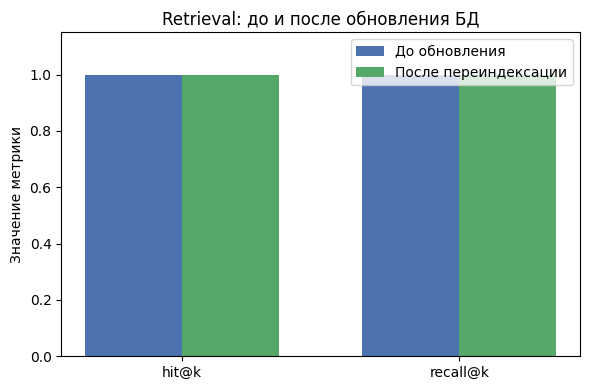

Сохранен график: artifacts/retrieval_quality_plot.png


,query,before_retrieved_sources,after_retrieved_sources,changed
0,"Что будет, если участник аукциона уронит цену ...",doc_9,doc_16,True
1,Что такое черный список от ФАС и как туда попа...,doc_5,doc_17,True
2,Для чего нужна банковская гарантия участнику?,doc_13,doc_15,True


Сохранен артефакт: artifacts/retrieval_before_after_update.csv


In [7]:
new_documents_batch = [
    {
        "doc_id": "doc_15",
        "text": "Независимая (банковская) гарантия — это документ, по которому банк обязуется выплатить заказчику определенную сумму, если поставщик нарушит условия контракта. Она часто используется участниками вместо перечисления 'живых' денег на счет заказчика."
    },
    {
        "doc_id": "doc_16",
        "text": "Антидемпинговые меры применяются в электронном аукционе, если участник торгов снижает начальную цену контракта более чем на 25 процентов. В такой ситуации победитель обязан предоставить увеличенное в полтора раза обеспечение исполнения контракта."
    },
    {
        "doc_id": "doc_17",
        "text": "Реестр недобросовестных поставщиков (РНП) — это специальный 'черный список', который ведет антимонопольная служба (ФАС). Попадание в РНП означает запрет на участие в государственных тендерах сроком на два года за срыв контракта или уклонение от его подписания."
    }
]

updated_kb = base_documents + new_documents_batch
print(f"Новый размер БД: {len(updated_kb)}")

# Переиндексация: пересчитываем чанки, эмбеддинги и FAISS-индекс для обновленной БД 
print("\n--- Переиндексация после обновления базы знаний ---")
artifacts_updated = build_retriever(updated_kb, chunk_size=30, overlap=10)
print(f"Чанков до обновления: {len(artifacts_base.chunks)}")
print(f"Чанков после переиндексации: {len(artifacts_updated.chunks)}")
print(f"Размер FAISS-индекса (ntotal): {artifacts_updated.index.ntotal}")
print("Переиндексация завершена.\n")

# Повторная оценка retrieval на контрольных запросах после переиндексации
df_eval_updated, metrics_updated = evaluate_retrieval(
    updated_kb, control_queries, top_k=3, ret_artifacts=artifacts_updated
)
print(f"Метрики после переиндексации (k=3): {metrics_updated}")

# Визуализация сравнения метрик до и после обновления
labels = ["hit@k", "recall@k"]
before_vals = [metrics_base["hit_at_k"], metrics_base["recall_at_k"]]
after_vals = [metrics_updated["hit_at_k"], metrics_updated["recall_at_k"]]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, before_vals, width, label="До обновления", color="#4C72B0")
ax.bar(x + width/2, after_vals, width, label="После переиндексации", color="#55A868")
ax.set_ylabel("Значение метрики")
ax.set_title("Retrieval: до и после обновления БД")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15)
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/retrieval_quality_plot.png", dpi=150)
plt.show()
print("Сохранен график: artifacts/retrieval_quality_plot.png")

# Сравнение выдачи до и после обновления
update_queries = [
    "Что будет, если участник аукциона уронит цену больше чем на 25 процентов?",
    "Что такое черный список от ФАС и как туда попадают?",
    "Для чего нужна банковская гарантия участнику?"
]

comparison = []
for q in update_queries:
    res_before = retrieve(q, artifacts_base, top_k=1)
    res_after = retrieve(q, artifacts_updated, top_k=1)
    
    doc_before = res_before[0]['doc_id'] if res_before else ""
    doc_after = res_after[0]['doc_id'] if res_after else ""
    
    comparison.append({
        "query": q,
        "before_retrieved_sources": doc_before,
        "after_retrieved_sources": doc_after,
        "changed": doc_before != doc_after
    })

df_update = pd.DataFrame(comparison)
display(df_update)
df_update.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
print("Сохранен артефакт: artifacts/retrieval_before_after_update.csv")

## 8. Mini-RAG (extractive подход)
Извлекаем наиболее релевантное предложение из найденного контекста.

In [8]:
import re

def extract_best_sentence(query: str, context: str, backend: EmbeddingBackend) -> str:
    sentences = [s.strip() for s in re.split(r'[.!?]+', context) if len(s.strip()) > 10]
    if not sentences:
        return ""
        
    q_vec = backend.encode([query])
    s_vecs = backend.encode(sentences)
    scores = np.dot(s_vecs, q_vec.T).flatten()
    best_idx = np.argmax(scores)
    return sentences[best_idx] + "."

def ask_mini_rag(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> dict:
    retrieved = retrieve(query, artifacts, top_k=top_k)
    context_chunks = [r['text'] for r in retrieved]
    full_context = " ".join(context_chunks)
    sources = [r['doc_id'] for r in retrieved]
    
    answer = extract_best_sentence(query, full_context, artifacts.backend)
    
    return {
        "question": query,
        "answer": answer,
        "retrieved_sources": ",".join(list(dict.fromkeys(sources))) 
    }

rag_questions = [
    "Какие последствия ждут участника, который снизил цену контракта больше чем на 25 процентов?",
    "В чем разница между закупками по 44-ФЗ и коммерческими тендерами?",
    "Можно ли использовать банковскую гарантию вместо денег, и для чего она нужна?",
    "Какое наказание предусмотрено для победителя тендера, который уклоняется от подписания контракта?",
    "Какая процедура лучше всего подходит для быстрой закупки недорогих товаров по критерию минимальной цены?",
    "Как участник может исправить опечатки или неприемлемые условия в контракте до его заключения?"
]

rag_results = []
for q in rag_questions:
    res = ask_mini_rag(q, artifacts_updated, top_k=3)
    rag_results.append(res)
    print(f"Q: {res['question']}")
    print(f"A: {res['answer']} (Источники: {res['retrieved_sources']})")


df_rag = pd.DataFrame(rag_results)
df_rag.to_csv("artifacts/rag_examples.csv", index=False)
print("Сохранен артефакт: artifacts/rag_examples.csv")

Q: Какие последствия ждут участника, который снизил цену контракта больше чем на 25 процентов?
A: В такой ситуации победитель обязан предоставить увеличенное в полтора раза обеспечение исполнения определенный процент от начальной цены контракта. (Источники: doc_16,doc_14)
Q: В чем разница между закупками по 44-ФЗ и коммерческими тендерами?
A: определенный процент от начальной цены контракта. (Источники: doc_14,doc_12,doc_3)
Q: Можно ли использовать банковскую гарантию вместо денег, и для чего она нужна?
A: Независимая (банковская) гарантия — это документ, по которому банк обязуется выплатить заказчику определенную сумму, если поставщик нарушит условия контракта. (Источники: doc_15,doc_13)
Q: Какое наказание предусмотрено для победителя тендера, который уклоняется от подписания контракта?
A: ситуации победитель обязан предоставить увеличенное в полтора раза обеспечение исполнения контракта. (Источники: doc_14,doc_16,doc_0)
Q: Какая процедура лучше всего подходит для быстрой закупки недо

### Анализ ошибок 

**Что получилось хорошо:**  
Модель (MiniLM + FAISS) показала метрику `hit@3 = 1.0`, безупречно понимая разницу между похожими тендерными терминами («обеспечение контракта» vs «обеспечение заявки»). Обновление словаря (добавление новых чанков) позволяет RAG-системе моментально учить новые факты (например, про демпинг на 25%) без переобучения весов языковой модели.

**Где RAG ошибается (ограничения экстрактивного подхода):**  
Так как мы не используем тяжелые генеративные LLM (Llama, GPT), а применяем алгоритм поиска «лучшего предложения» (`extract_best_sentence`), система может дать некорректный ответ, если:
1. Факт разбит на 2 соседних предложения (мы вырезаем только одно, обрывая мысль).
2. Задан концептуальный вопрос «В чем разница между X и Y». Экстрактор не может синтезировать сравнение, а просто находит предложение, где эти термины стоят рядом (что порождает частичные "галлюцинации" или обрезки).